# LH Nautical — Data Analysis Project

In [770]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import sqlite3
import matplotlib.pyplot as plt
import duckdb
from IPython.display import Image, display

## Questão 1 - EDA

### Caminho base do projeto

In [771]:
BASE_PATH = Path().resolve()

while BASE_PATH.name != "lh-nautical-data-project":
    BASE_PATH = BASE_PATH.parent

print(f"BASE PATH: {BASE_PATH}")

BASE PATH: /Users/richardgomes/lh-nautical-data-project


Carregando os dados em um dataframe Pandas para melhor visulização. 

In [772]:
DATA_PATH = BASE_PATH / "data"

RAW_PATH = DATA_PATH / "raw"
STAGING_PATH = DATA_PATH / "staging"
INTERMEDIATE_PATH = DATA_PATH / "intermediate"
MARTS_PATH = DATA_PATH / "marts"

SQL_PATH = BASE_PATH / "sql"
IMAGES_PATH = BASE_PATH / "imagens"

In [773]:
df_vendas = pd.read_csv(RAW_PATH / "vendas_2023_2024.csv", encoding="utf-8")

Parte 1 - Visão geral do dataset

In [774]:
conn = sqlite3.connect(':memory:')

In [775]:
df_vendas.to_sql('vendas', conn, index=False, if_exists='replace')

9895

Quantidade total de linhas

In [776]:
query = """
SELECT COUNT(*) AS total_linhas
FROM vendas
"""

pd.read_sql(query, conn)

,total_linhas
0,9895


Quantidade total de colunas

In [777]:
query = """
SELECT COUNT(*) AS total_colunas
FROM pragma_table_info('vendas')
"""

pd.read_sql(query, conn)

,total_colunas
0,6


Intervalo d e datas analisado (data mínima e
máxima)

In [778]:
df_vendas.columns

Index(['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date'], dtype='str')

In [779]:
query = """
SELECT 
    MIN(sale_date) AS data_min,
    MAX(sale_date) AS data_max
FROM vendas
"""

pd.read_sql(query, conn)

,data_min,data_max
0,01-01-2023,31-12-2024


 Questão 1.1 - SQL
Código calculando:
• Quantidade total d e linhas
• Quantidade total de colunas
• Intervalo de datas analisado (data mínima e máxima)
• Valor mínimo
• Valor máximo
• Valor médio

Query resposta:

In [780]:
"""
SELECT 
    COUNT(*) AS total_linhas,
    (SELECT COUNT(*) FROM pragma_table_info('vendas')) AS total_colunas,
    MIN(sale_date) AS data_min,
    MAX(sale_date) AS data_max,
    MIN(total) AS valor_min,
    MAX(total) AS valor_max,
    AVG(total) AS valor_medio
FROM vendas
"""


"\nSELECT \n    COUNT(*) AS total_linhas,\n    (SELECT COUNT(*) FROM pragma_table_info('vendas')) AS total_colunas,\n    MIN(sale_date) AS data_min,\n    MAX(sale_date) AS data_max,\n    MIN(total) AS valor_min,\n    MAX(total) AS valor_max,\n    AVG(total) AS valor_medio\nFROM vendas\n"

In [781]:
query = """
SELECT 
    COUNT(*) AS total_linhas,
    (SELECT COUNT(*) FROM pragma_table_info('vendas')) AS total_colunas,
    MIN(sale_date) AS data_min,
    MAX(sale_date) AS data_max,
    MIN(total) AS valor_min,
    MAX(total) AS valor_max,
    AVG(total) AS valor_medio
FROM vendas
"""

pd.read_sql(query, conn)

,total_linhas,total_colunas,data_min,data_max,valor_min,valor_max,valor_medio
0,9895,6,01-01-2023,31-12-2024,294.5,2222973.0,263797.828267


Questão 1.2 - Validação
Qual é o valor máximo registrado na coluna "total"?

In [782]:
query = """
SELECT MAX(total) AS valor_maximo
FROM vendas;
"""
pd.read_sql(query, conn)

,valor_maximo
0,2222973.0


Questão 1.3 - Interpretação
Com base na análise exploratória real

In [783]:
df_vendas['total'].describe()

count    9.895000e+03
mean     2.637978e+05
std      3.900072e+05
min      2.945000e+02
25%      2.313820e+04
50%      8.222500e+04
75%      3.390945e+05
max      2.222973e+06
Name: total, dtype: float64

In [784]:
df_vendas.isnull().sum()

id            0
id_client     0
id_product    0
qtd           0
total         0
sale_date     0
dtype: int64

In [785]:
df_vendas.duplicated().sum()

np.int64(0)

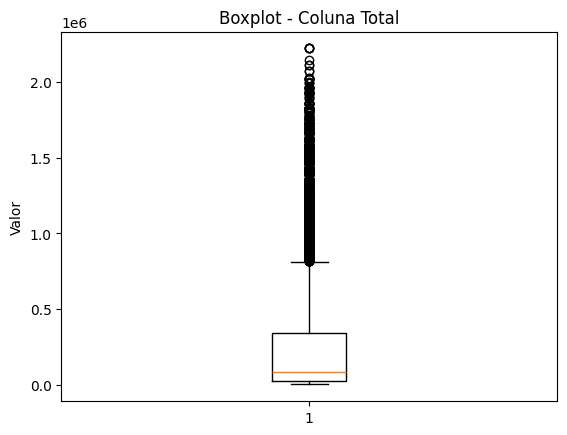

In [786]:


plt.figure()
plt.boxplot(df_vendas['total'])
plt.title('Boxplot - Coluna Total')
plt.ylabel('Valor')
plt.show()

O dataset tem um intervalo consistente de datas dos anos de 2023 a 2024 em estrutura simples, colunas bem definidas, e isso facilita a análise inicial.
Mas, aparentemente pode haver outliers na coluna "total", já que o valor máximo 2.222.973 é muito superior à média, que é de mais ou menos 263.798, isso mosta grande dispersão nos dados. E indica issopossíveis inconsistências que devem ser investigadas.
Não encontrei problemas estruturais na qualidade dos dados, como ausência de colunas ou falhas de leitura.

### Parte 2 - Análise de valores numéricos

## Questão 2 - Produtos

In [787]:
df_produtos = pd.read_csv(RAW_PATH / "produtos_raw.csv", encoding="utf-8")

Parte 1 - Padronize os nomes das categorias d e
produtos em: eletrônicos, propulsão e ancoragem.

In [788]:
df_produtos.shape

(157, 4)

In [789]:
df_produtos.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   name             157 non-null    str  
 1   price            157 non-null    str  
 2   code             157 non-null    int64
 3   actual_category  157 non-null    str  
dtypes: int64(1), str(3)
memory usage: 5.0 KB


In [790]:
df_produtos["actual_category"].unique()

<StringArray>
[          'ELETRONICOS', 'E L E T R Ô N I C O S',           'Eletrunicos',
           'Eletronicoz',           'eLeTrÔnIcOs',           'eletrônicos',
           'Eletrônicos',          'Eletroniscos',           'Eletronicos',
           'eletronicos',           'EletrônicoS',           'ELEtRÔNICOS',
             'PROPULSAO',             'Propulção',                  'Prop',
            'Propulssão',             'propulsao',     'P R O P U L S Ã O',
              'Propução',             'propulsão',             'pRoPuLsÃo',
             'Propulçao',             'Propulsam',             'PrOpUlSãO',
             'Ancoragem',             'AnCoRaGeM',             'Encoragem',
            'Ancoraguem',              'Ancorajm',             'AncorageM',
     'A N C O R A G E M',             'ANCORAGEM',             'aNcOrAgEm',
             'Ancorajem',              'Encoragi',             'ancoragem',
             'Ancorajen',             'AncorajeM',             'Ancoragen'

In [791]:
df_produtos["actual_category_clean"] = (
    df_produtos["actual_category"]
    .str.lower()
    .str.strip()
)

df_produtos["actual_category_clean"].unique()

<StringArray>
[          'eletronicos', 'e l e t r ô n i c o s',           'eletrunicos',
           'eletronicoz',           'eletrônicos',          'eletroniscos',
             'propulsao',             'propulção',                  'prop',
            'propulssão',     'p r o p u l s ã o',              'propução',
             'propulsão',             'propulçao',             'propulsam',
             'ancoragem',             'encoragem',            'ancoraguem',
              'ancorajm',     'a n c o r a g e m',             'ancorajem',
              'encoragi',             'ancorajen',             'ancoragen']
Length: 24, dtype: str

In [792]:
import unicodedata

def remover_acentos(texto):
    if isinstance(texto, str):
        return unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    return texto

df_produtos["actual_category_clean"] = df_produtos["actual_category_clean"].apply(remover_acentos)

df_produtos["actual_category_clean"].unique()

<StringArray>
[          'eletronicos', 'e l e t r o n i c o s',           'eletrunicos',
           'eletronicoz',          'eletroniscos',             'propulsao',
             'propulcao',                  'prop',            'propulssao',
     'p r o p u l s a o',              'propucao',             'propulsam',
             'ancoragem',             'encoragem',            'ancoraguem',
              'ancorajm',     'a n c o r a g e m',             'ancorajem',
              'encoragi',             'ancorajen',             'ancoragen']
Length: 21, dtype: str

Remoção de espaços internos nas categorias

In [793]:
df_produtos["actual_category_clean"] = (
    df_produtos["actual_category_clean"]
    .str.replace(" ", "", regex=False)
)

df_produtos["actual_category_clean"].unique()

<StringArray>
[ 'eletronicos',  'eletrunicos',  'eletronicoz', 'eletroniscos',
    'propulsao',    'propulcao',         'prop',   'propulssao',
     'propucao',    'propulsam',    'ancoragem',    'encoragem',
   'ancoraguem',     'ancorajm',    'ancorajem',     'encoragi',
    'ancorajen',    'ancoragen']
Length: 18, dtype: str

Padronização das categorias

In [794]:
def padronizar_categoria(cat):
    if "eletro" in cat:
        return "eletronicos"
    elif "prop" in cat:
        return "propulsao"
    elif "ancor" in cat:
        return "ancoragem"
    else:
        return "outros"

In [795]:
df_produtos["category_final"] = df_produtos["actual_category_clean"].apply(padronizar_categoria)

df_produtos["category_final"].unique()

<StringArray>
['eletronicos', 'outros', 'propulsao', 'ancoragem']
Length: 4, dtype: str

In [796]:
df_produtos[df_produtos["category_final"] == "outros"]["actual_category_clean"].unique()

<StringArray>
['eletrunicos', 'encoragem', 'encoragi']
Length: 3, dtype: str

In [797]:
def padronizar_categoria(cat):
    if "eletro" in cat or "eletru" in cat:
        return "eletronicos"
    elif "prop" in cat:
        return "propulsao"
    elif "ancor" in cat or "encor" in cat:
        return "ancoragem"
    else:
        return "outros"

In [798]:
df_produtos["category_final"] = df_produtos["actual_category_clean"].apply(padronizar_categoria)

df_produtos["category_final"].unique()

<StringArray>
['eletronicos', 'propulsao', 'ancoragem']
Length: 3, dtype: str

In [799]:
df_produtos.head()

,name,price,code,actual_category,actual_category_clean,category_final
0,Transponder AIS Maré Magnum,R$ 33122.52,1,ELETRONICOS,eletronicos,eletronicos
1,Transponder Furuno Marlin,R$ 13998.15,2,ELETRONICOS,eletronicos,eletronicos
2,Radar Furuno Pulse Leviathan,R$ 9024.19,3,E L E T R Ô N I C O S,eletronicos,eletronicos
3,Rádio AIS Hydro Tidal Zen,R$ 3381.88,4,Eletrunicos,eletrunicos,eletronicos
4,Piloto Automático Furuno Storm,R$ 23669.01,5,Eletronicoz,eletronicoz,eletronicos


In [800]:
df_produtos = df_produtos[[
    "name",
    "price",
    "code",
    "category_final"
]].rename(columns={
    "name": "nome_produto",
    "price": "preco",
    "code": "codigo_produto",
    "category_final": "categoria"
})

df_produtos

,nome_produto,preco,codigo_produto,categoria
0,Transponder AIS Maré Magnum,R$ 33122.52,1,eletronicos
1,Transponder Furuno Marlin,R$ 13998.15,2,eletronicos
2,Radar Furuno Pulse Leviathan,R$ 9024.19,3,eletronicos
3,Rádio AIS Hydro Tidal Zen,R$ 3381.88,4,eletronicos
4,Piloto Automático Furuno Storm,R$ 23669.01,5,eletronicos
...,...,...,...,...
152,Corrente Delta Vox Ion,R$ 495.98,146,ancoragem
153,Corrente Danforth Force Leviathan Impulse,R$ 3030.08,147,ancoragem
154,Âncora Delta Force Barracuda Mako,R$ 4785.56,148,ancoragem
155,Cabo de Nylon Bruce Core,R$ 1163.62,149,ancoragem


In [801]:
df_produtos.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   nome_produto    157 non-null    str  
 1   preco           157 non-null    str  
 2   codigo_produto  157 non-null    int64
 3   categoria       157 non-null    str  
dtypes: int64(1), str(3)
memory usage: 5.0 KB


Parte 2 - Converta os valores para o tipo
numérico.

In [802]:
df_produtos["preco"] = (
    df_produtos["preco"]
    .str.replace("R$", "", regex=False)
    .str.strip()
    .astype(float)
)

In [803]:
print(df_produtos['preco'].dtype)

float64



Parte 3 - Remova as duplicatas.

verificando os duplicados

In [804]:
duplicados_antes = df_produtos.duplicated().sum()
df_produtos = df_produtos.drop_duplicates()
duplicados_depois = df_produtos.duplicated().sum()
duplicados_removidos = duplicados_antes - duplicados_depois
duplicados_removidos

np.int64(7)

Removendo os duplicados.

In [805]:
duplicados_removidos = df_produtos.duplicated().sum()
duplicados_removidos

np.int64(0)

Questão 2.1 - Faça o upload de seu código
Python

Link para o arquivo questao_2.1.py :

In [806]:
print(f"SCRIPT PATH: {BASE_PATH / 'questao_2.1.py'}")

SCRIPT PATH: /Users/richardgomes/lh-nautical-data-project/questao_2.1.py


In [807]:
# Código do arquivo questao_2.1.py

"""
# Questão 2 - Produtos

import pandas as pd
from pathlib import Path
import unicodedata

BASE_PATH = Path().resolve()

while BASE_PATH.name != "lh-nautical-data-project":
    BASE_PATH = BASE_PATH.parent

print(f"BASE PATH: {BASE_PATH}")

DATA_PATH = BASE_PATH / "data"
RAW_PATH = DATA_PATH / "raw"

print(f"RAW PATH: {RAW_PATH}")


df_produtos = pd.read_csv(RAW_PATH / "produtos_raw.csv", encoding="utf-8")


# Parte 1 - Padronize os nomes das categorias d e produtos em: eletrônicos, propulsão e ancoragem.

df_produtos.shape

df_produtos.info()

df_produtos["actual_category"].unique()

df_produtos["actual_category_clean"] = (
    df_produtos["actual_category"]
    .str.lower()
    .str.strip()
)

df_produtos["actual_category_clean"].unique()

import unicodedata

def remover_acentos(texto):
    if isinstance(texto, str):
        return unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")
    return texto

df_produtos["actual_category_clean"] = df_produtos["actual_category_clean"].apply(remover_acentos)

df_produtos["actual_category_clean"].unique()

# Remoção de espaços internos nas categorias


df_produtos["actual_category_clean"] = (
    df_produtos["actual_category_clean"]
    .str.replace(" ", "", regex=False)
)

df_produtos["actual_category_clean"].unique()

# Padronização das categorias

def padronizar_categoria(cat):
    if "eletro" in cat:
        return "eletronicos"
    elif "prop" in cat:
        return "propulsao"
    elif "ancor" in cat:
        return "ancoragem"
    else:
        return "outros"

df_produtos["category_final"] = df_produtos["actual_category_clean"].apply(padronizar_categoria)

df_produtos["category_final"].unique()


df_produtos[df_produtos["category_final"] == "outros"]["actual_category_clean"].unique()


def padronizar_categoria(cat):
    if "eletro" in cat or "eletru" in cat:
        return "eletronicos"
    elif "prop" in cat:
        return "propulsao"
    elif "ancor" in cat or "encor" in cat:
        return "ancoragem"
    else:
        return "outros"


df_produtos["category_final"] = df_produtos["actual_category_clean"].apply(padronizar_categoria)

df_produtos["category_final"].unique()


df_produtos = df_produtos[[
    "name",
    "price",
    "code",
    "category_final"
]].rename(columns={
    "name": "nome_produto",
    "price": "preco",
    "code": "codigo_produto",
    "category_final": "categoria"
})

df_produtos

df_produtos.info()


# Parte 2 - Converta os valores para o tipo numérico.


df_produtos["preco"] = (
    df_produtos["preco"]
    .str.replace("R$", "", regex=False)
    .str.strip()
    .astype(float)
)

print(df_produtos['preco'].dtype)


# Parte 3 - Remova as duplicatas.

# verificando os duplicados


duplicados_antes = df_produtos.duplicated().sum()
df_produtos = df_produtos.drop_duplicates()
duplicados_depois = df_produtos.duplicated().sum()
duplicados_removidos = duplicados_antes - duplicados_depois
duplicados_removidos

# Removendo os duplicados.

duplicados_removidos = df_produtos.duplicated().sum()
duplicados_removidos

"""

'\n# Questão 2 - Produtos\n\nimport pandas as pd\nfrom pathlib import Path\nimport unicodedata\n\nBASE_PATH = Path().resolve()\n\nwhile BASE_PATH.name != "lh-nautical-data-project":\n    BASE_PATH = BASE_PATH.parent\n\nprint(f"BASE PATH: {BASE_PATH}")\n\nDATA_PATH = BASE_PATH / "data"\nRAW_PATH = DATA_PATH / "raw"\n\nprint(f"RAW PATH: {RAW_PATH}")\n\n\ndf_produtos = pd.read_csv(RAW_PATH / "produtos_raw.csv", encoding="utf-8")\n\n\n# Parte 1 - Padronize os nomes das categorias d e produtos em: eletrônicos, propulsão e ancoragem.\n\ndf_produtos.shape\n\ndf_produtos.info()\n\ndf_produtos["actual_category"].unique()\n\ndf_produtos["actual_category_clean"] = (\n    df_produtos["actual_category"]\n    .str.lower()\n    .str.strip()\n)\n\ndf_produtos["actual_category_clean"].unique()\n\nimport unicodedata\n\ndef remover_acentos(texto):\n    if isinstance(texto, str):\n        return unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")\n    return texto\n\ndf_produtos

Questão 2.2 - Validação
Quantos produtos duplicados foram removidos? = 7

## Questão 3 - Custos de Importação

Leitura e carregamento dos dados dos custos de importação (custos_importacao.json)

In [808]:
with open(RAW_PATH / "custos_importacao.json", "r", encoding="utf-8") as f:
    custos_importacao_json = json.load(f)

In [809]:
custos_importacao = pd.json_normalize(custos_importacao_json)

In [810]:
custos_importacao.shape

(150, 4)

In [811]:
custos_importacao.head(10)

,product_id,product_name,category,historic_data
0,1,Transponder AIS Maré Magnum,eletrônicos,"[{'start_date': '10/08/2016', 'usd_price': 105..."
1,2,Transponder Furuno Marlin,eletrônicos,"[{'start_date': '23/11/2017', 'usd_price': 432..."
2,3,Radar Furuno Pulse Leviathan,eletrônicos,"[{'start_date': '12/04/2016', 'usd_price': 254..."
3,4,Rádio AIS Hydro Tidal Zen,eletrônicos,"[{'start_date': '04/03/2016', 'usd_price': 909..."
4,5,Piloto Automático Furuno Storm,eletrônicos,"[{'start_date': '10/02/2016', 'usd_price': 600..."
5,6,Transponder AIS Vector,eletrônicos,"[{'start_date': '23/07/2020', 'usd_price': 228..."
6,7,Radar AIS Zen,eletrônicos,"[{'start_date': '26/10/2016', 'usd_price': 625..."
7,8,GPS AIS Zen,eletrônicos,"[{'start_date': '06/12/2019', 'usd_price': 119..."
8,9,Transponder AIS Titan Pulse,eletrônicos,"[{'start_date': '26/12/2018', 'usd_price': 101..."
9,10,Piloto Automático Simrad Titan Flux Magnum,eletrônicos,"[{'start_date': '29/05/2018', 'usd_price': 859..."


Compreendendo o conteúdo de "historic_data"

In [812]:
custos_importacao["historic_data"].iloc[0]

[{'start_date': '10/08/2016', 'usd_price': 10583.63},
 {'start_date': '15/06/2018', 'usd_price': 8778.36},
 {'start_date': '25/09/2018', 'usd_price': 8023.87},
 {'start_date': '19/03/2019', 'usd_price': 8772.78},
 {'start_date': '17/01/2020', 'usd_price': 7918.18},
 {'start_date': '17/06/2020', 'usd_price': 6310.01},
 {'start_date': '02/07/2021', 'usd_price': 6586.7},
 {'start_date': '16/05/2022', 'usd_price': 6538.2},
 {'start_date': '28/02/2023', 'usd_price': 6360.91},
 {'start_date': '17/10/2023', 'usd_price': 6574.8},
 {'start_date': '16/02/2024', 'usd_price': 6657.12},
 {'start_date': '22/02/2024', 'usd_price': 6703.2},
 {'start_date': '15/03/2024', 'usd_price': 6633.66},
 {'start_date': '02/08/2024', 'usd_price': 5774.5},
 {'start_date': '08/04/2025', 'usd_price': 5579.75}]

Várias datas para apenas um único produto.
Vai ser preciso "explodir" a coluna

In [813]:
custos_importacao_exploded = custos_importacao.explode("historic_data")

custos_importacao_exploded.head()

,product_id,product_name,category,historic_data
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '10/08/2016', 'usd_price': 1058..."
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '15/06/2018', 'usd_price': 8778..."
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '25/09/2018', 'usd_price': 8023..."
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '19/03/2019', 'usd_price': 8772..."
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '17/01/2020', 'usd_price': 7918..."


Agora já dá pra separar em colunas, extraindo os campos do dicionário.

In [814]:
custos_importacao_exploded["start_date"] = custos_importacao_exploded["historic_data"].apply(lambda x: x["start_date"])

custos_importacao_exploded["usd_price"] = custos_importacao_exploded["historic_data"].apply(lambda x: x["usd_price"])

custos_importacao_exploded.head()

,product_id,product_name,category,historic_data,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '10/08/2016', 'usd_price': 1058...",10/08/2016,10583.63
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '15/06/2018', 'usd_price': 8778...",15/06/2018,8778.36
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '25/09/2018', 'usd_price': 8023...",25/09/2018,8023.87
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '19/03/2019', 'usd_price': 8772...",19/03/2019,8772.78
0,1,Transponder AIS Maré Magnum,eletrônicos,"{'start_date': '17/01/2020', 'usd_price': 7918...",17/01/2020,7918.18


Agora posso montar as colunas  finais para como foi pedido. 

In [815]:
custos_importacao_final = custos_importacao_exploded[[
    "product_id",
    "product_name",
    "category",
    "start_date",
    "usd_price"
]]

custos_importacao_final.head()

,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,10/08/2016,10583.63
0,1,Transponder AIS Maré Magnum,eletrônicos,15/06/2018,8778.36
0,1,Transponder AIS Maré Magnum,eletrônicos,25/09/2018,8023.87
0,1,Transponder AIS Maré Magnum,eletrônicos,19/03/2019,8772.78
0,1,Transponder AIS Maré Magnum,eletrônicos,17/01/2020,7918.18


In [816]:
custos_importacao_final.info()

<class 'pandas.DataFrame'>
Index: 1260 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    1260 non-null   int64  
 1   product_name  1260 non-null   str    
 2   category      1260 non-null   str    
 3   start_date    1260 non-null   str    
 4   usd_price     1260 non-null   float64
dtypes: float64(1), int64(1), str(3)
memory usage: 59.1 KB


Tive que corrigir o tipo da data de "start_date"

In [817]:
custos_importacao_final["start_date"] = pd.to_datetime(
    custos_importacao_final["start_date"],
    dayfirst=True
)

In [818]:
custos_importacao_final.info()

<class 'pandas.DataFrame'>
Index: 1260 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    1260 non-null   int64         
 1   product_name  1260 non-null   str           
 2   category      1260 non-null   str           
 3   start_date    1260 non-null   datetime64[us]
 4   usd_price     1260 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 59.1 KB


In [819]:
custos_importacao_final.head()

,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,2016-08-10,10583.63
0,1,Transponder AIS Maré Magnum,eletrônicos,2018-06-15,8778.36
0,1,Transponder AIS Maré Magnum,eletrônicos,2018-09-25,8023.87
0,1,Transponder AIS Maré Magnum,eletrônicos,2019-03-19,8772.78
0,1,Transponder AIS Maré Magnum,eletrônicos,2020-01-17,7918.18


Questão 3.1 - Faça o upload de seu código Python


Link para o arquivo questao_3.1.py :

In [820]:
print(f"SCRIPT PATH: {BASE_PATH / 'questao_3.1.py'}")

SCRIPT PATH: /Users/richardgomes/lh-nautical-data-project/questao_3.1.py


Questão 3.2 - Validação
Quantas entradas de importação o CSV recebeu ao todo
após a normalização? = 

In [821]:
len(custos_importacao_final)

1260

## Questão 4 - Dados Públicos

Dados públicos do Olinda, sistema de APIs públicas do Banco Central

"A Plataforma Olinda é o módulo de regulação digital do Banco Central do Brasil"

Tive que colocar o periodo que eu precisava na própria URL, não consegui de outra forma

In [822]:
import pandas as pd
import requests

url = "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?@dataInicial='01-01-2023'&@dataFinalCotacao='12-31-2024'&$top=10000&$format=json"

response = requests.get(url)
data = response.json()

cambio = pd.DataFrame(data['value'])

cambio['data'] = pd.to_datetime(cambio['dataHoraCotacao']).dt.date
cambio['taxa_cambio'] = cambio['cotacaoVenda']

cambio = cambio[['data', 'taxa_cambio']]
cambio = cambio.sort_values('data').drop_duplicates('data', keep='last')

cambio.head()

,data,taxa_cambio
0,2023-01-02,5.3436
1,2023-01-03,5.3759
2,2023-01-04,5.4459
3,2023-01-05,5.4026
4,2023-01-06,5.2855


Criar calendário completo + preencher com último valor conhecido

In [823]:
calendario = pd.DataFrame({
    'data': pd.date_range(
        start=cambio['data'].min(),
        end=cambio['data'].max()
    )
})

cambio['data'] = pd.to_datetime(cambio['data'])
cambio_completo = calendario.merge(cambio, on='data', how='left')
cambio_completo['taxa_cambio'] = cambio_completo['taxa_cambio'].ffill()

cambio_completo.head(10)

,data,taxa_cambio
0,2023-01-02,5.3436
1,2023-01-03,5.3759
2,2023-01-04,5.4459
3,2023-01-05,5.4026
4,2023-01-06,5.2855
5,2023-01-07,5.2855
6,2023-01-08,5.2855
7,2023-01-09,5.2967
8,2023-01-10,5.2395
9,2023-01-11,5.2020


Salvei a tabela para garantir acesso mais fácil

In [824]:
cambio_completo.to_csv(STAGING_PATH /"cambio_diario.csv", index=False)

Parte 1 - Cálculo e modelagem

Preparação para a query em SQL

In [825]:
conn = sqlite3.connect(":memory:")

pd.read_csv("../data/staging/stg_vendas.csv").to_sql("stg_vendas", conn, index=False, if_exists="replace")
pd.read_csv("../data/staging/stg_custos_importacao_tratado.csv").to_sql("stg_custos", conn, index=False, if_exists="replace")
pd.read_csv("../data/staging/cambio_diario.csv").to_sql("cambio", conn, index=False, if_exists="replace")

730

Conferindo a granularidade dos dados

Para stg_vendas.csv

In [826]:
query = """
SELECT 
    COUNT(*) AS total_linhas,
    COUNT(DISTINCT id_venda) AS vendas_unicas
FROM stg_vendas
"""
base_vendas = pd.read_sql_query(query, conn)
base_vendas.head()

,total_linhas,vendas_unicas
0,9895,9895


E para cambio_diario.csv

In [827]:
query = """
SELECT
    COUNT(*) AS total_linhas,
    COUNT(DISTINCT data) AS datas_unicas
FROM cambio
"""

pd.read_sql_query(query, conn)

,total_linhas,datas_unicas
0,730,730


Para stg_custos_importacao_tratado.csv

In [828]:
query = """
SELECT
    COUNT(*) AS total_linhas,
    COUNT(DISTINCT id_produto) AS produtos_unicos
FROM stg_custos
"""

pd.read_sql_query(query, conn)

,total_linhas,produtos_unicos
0,1260,150


Optei por usar o usar custo mais recente por produto

Parte 1 - Cálculo e modelagem
• Calcule o custo total e m BRL por transação
• Identifique transações com prejuízo
• Agregue os dados por id_produto, gerando:
1. Receita total (BRL)
2. Prejuízo total (BRL)
3. Percentual de perda (prejuízo_total /
receita_total)

In [829]:
query = """
WITH custos_recentes AS (
    SELECT
        id_produto,
        preco_usd
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY id_produto
                   ORDER BY data_inicio DESC
               ) as rn
        FROM stg_custos
    )
    WHERE rn = 1
)

SELECT
    v.id_produto,
    SUM(v.valor_total) AS receita_total,
    SUM(
        CASE 
            WHEN (c.preco_usd * tc.taxa_cambio - v.valor_total) > 0 
            THEN (c.preco_usd * tc.taxa_cambio - v.valor_total)
            ELSE 0
        END
    ) AS prejuizo_total,
    
    SUM(
        CASE 
            WHEN (c.preco_usd * tc.taxa_cambio - v.valor_total) > 0 
            THEN (c.preco_usd * tc.taxa_cambio - v.valor_total)
            ELSE 0
        END
    ) * 1.0 / SUM(v.valor_total) AS percentual_prejuizo

FROM stg_vendas v

LEFT JOIN custos_recentes c
    ON v.id_produto = c.id_produto

LEFT JOIN cambio tc
    ON v.data_venda = tc.data

GROUP BY v.id_produto
"""

resultado = pd.read_sql_query(query, conn)

resultado.head()

,id_produto,receita_total,prejuizo_total,percentual_prejuizo
0,1,17187280.35,154.709200,0.000009
1,2,8862231.15,21.358768,0.000002
2,3,4322136.25,2318.092263,0.000536
3,4,1915160.00,29.978055,0.000016
4,5,13494880.35,1091.034870,0.000081


In [830]:
resultado.to_csv("../data/staging/indicadores_financeiros_produtos.csv", index=False)

Parte 2 - Análise visual

In [831]:
df = pd.read_csv("../data/staging/indicadores_financeiros_produtos.csv")
df_produtos = pd.read_csv("../data/staging/stg_custos_importacao_tratado.csv")
df_produtos = df_produtos[["id_produto", "nome_produto"]].drop_duplicates()
df = df.merge(df_produtos, on="id_produto", how="left")

In [832]:
df["produto_label"] = df["nome_produto"] + " (ID " + df["id_produto"].astype(str) + ")"

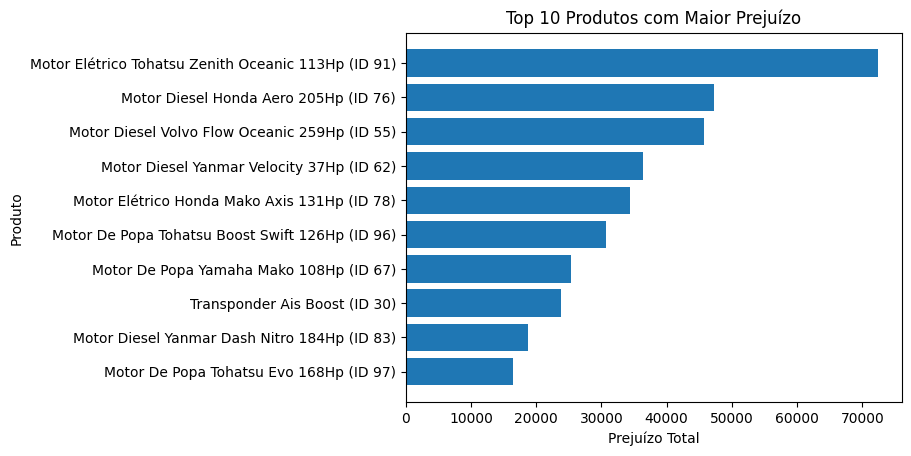

In [833]:
top10 = df.sort_values("prejuizo_total", ascending=False).head(10)

plt.figure()
plt.barh(top10["produto_label"], top10["prejuizo_total"])
plt.title("Top 10 Produtos com Maior Prejuízo")
plt.xlabel("Prejuízo Total")
plt.ylabel("Produto")
plt.gca().invert_yaxis()

plt.show()

Parte 3 - Análise objetiva Responda

In [834]:
df = pd.read_csv("../data/staging/indicadores_financeiros_produtos.csv")

In [835]:
df = pd.read_csv("../data/staging/indicadores_financeiros_produtos.csv")
df_produtos = pd.read_csv("../data/staging/stg_custos_importacao_tratado.csv")
df_produtos = df_produtos[["id_produto", "nome_produto"]].drop_duplicates()
df = df.merge(df_produtos, on="id_produto", how="left")

In [836]:
maior_prejuizo = df.loc[[df["prejuizo_total"].idxmax()]]
maior_prejuizo[["id_produto", "nome_produto", "prejuizo_total"]]

,id_produto,nome_produto,prejuizo_total
90,91,Motor Elétrico Tohatsu Zenith Oceanic 113Hp,72420.727535


In [837]:
maior_percentual = df.loc[[df["percentual_prejuizo"].idxmax()]]
maior_percentual[["id_produto", "nome_produto", "percentual_prejuizo"]]

,id_produto,nome_produto,percentual_prejuizo
103,104,Cabo De Nylon Delta Zen Vortex Storm,0.002637


In [838]:
produto_abs = maior_prejuizo["id_produto"].values[0]
produto_pct = maior_percentual["id_produto"].values[0]

nome_abs = maior_prejuizo["nome_produto"].values[0]
nome_pct = maior_percentual["nome_produto"].values[0]

mesmo = produto_abs == produto_pct

print(f"Produto com maior prejuízo absoluto: {nome_abs}")

if mesmo:
    print("É o mesmo produto com maior percentual de perda: SIM")
else:
    print("É o mesmo produto com maior percentual de perda: NÃO")
    print(f"Produto com maior percentual de perda: {nome_pct}")

Produto com maior prejuízo absoluto: Motor Elétrico Tohatsu Zenith Oceanic 113Hp
É o mesmo produto com maior percentual de perda: NÃO
Produto com maior percentual de perda: Cabo De Nylon Delta Zen Vortex Storm


Questão 4.1 - Código SQL

In [839]:
"""
WITH custos_recentes AS (
    SELECT
        id_produto,
        preco_usd
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY id_produto
                   ORDER BY data_inicio DESC
               ) as rn
        FROM stg_custos
    )
    WHERE rn = 1
)

SELECT
    v.id_produto,
    SUM(v.valor_total) AS receita_total,
    SUM(
        CASE 
            WHEN (c.preco_usd * tc.taxa_cambio - v.valor_total) > 0 
            THEN (c.preco_usd * tc.taxa_cambio - v.valor_total)
            ELSE 0
        END
    ) AS prejuizo_total,
    
    SUM(
        CASE 
            WHEN (c.preco_usd * tc.taxa_cambio - v.valor_total) > 0 
            THEN (c.preco_usd * tc.taxa_cambio - v.valor_total)
            ELSE 0
        END
    ) * 1.0 / SUM(v.valor_total) AS percentual_prejuizo

FROM stg_vendas v

LEFT JOIN custos_recentes c
    ON v.id_produto = c.id_produto

LEFT JOIN cambio tc
    ON v.data_venda = tc.data

GROUP BY v.id_produto
"""

'\nWITH custos_recentes AS (\n    SELECT\n        id_produto,\n        preco_usd\n    FROM (\n        SELECT *,\n               ROW_NUMBER() OVER (\n                   PARTITION BY id_produto\n                   ORDER BY data_inicio DESC\n               ) as rn\n        FROM stg_custos\n    )\n    WHERE rn = 1\n)\n\nSELECT\n    v.id_produto,\n    SUM(v.valor_total) AS receita_total,\n    SUM(\n        CASE \n            WHEN (c.preco_usd * tc.taxa_cambio - v.valor_total) > 0 \n            THEN (c.preco_usd * tc.taxa_cambio - v.valor_total)\n            ELSE 0\n        END\n    ) AS prejuizo_total,\n\n    SUM(\n        CASE \n            WHEN (c.preco_usd * tc.taxa_cambio - v.valor_total) > 0 \n            THEN (c.preco_usd * tc.taxa_cambio - v.valor_total)\n            ELSE 0\n        END\n    ) * 1.0 / SUM(v.valor_total) AS percentual_prejuizo\n\nFROM stg_vendas v\n\nLEFT JOIN custos_recentes c\n    ON v.id_produto = c.id_produto\n\nLEFT JOIN cambio tc\n    ON v.data_venda = tc.data\n

Questão 4.2 - Validação.

Qual é o id_produto que apresentou a maior
porcentagem de perda financeira relativa (maior % de
prejuízo sobre sua receita) no período analisado? = 104

In [840]:
df = pd.read_csv("../data/staging/indicadores_financeiros_produtos.csv")
df.loc[[df["percentual_prejuizo"].idxmax()]]

,id_produto,receita_total,prejuizo_total,percentual_prejuizo
103,104,1275786.8,3364.342328,0.002637


Questão 4.3 - Interpretação

Qual data de câmbio você utilizou?

Utilizei a taxa de câmbio do dia da venda "data_venda", com um join da tabela de câmbio diário "cambio_diario" usando as datas.

Como definiu o prejuízo?

O prejuízo foi calculado da diferença entre o custo do produto convertido em BRL e o valor total da venda. Quando o custo em BRL (preco_usd * taxa_cambio) foi maior que o valor da venda, a transação teve prejuízo.

Alguma suposição relevante?

Usei o custo mais recente de cada produto, com base na data de início "data_inicio", para simplificar o modelo.

## Questão 5 - Análise de clientes

Análise com o Pandas

Para fazer essa análise usei os arquivos arquivos csv que preparei para uma camada staging.

Como se trata de uma análise de comportamento de compras, vou apresentar os clientes apenas pelo id_cliente aqui. 

Acredito que informações mais detalhadas sobre os clientes, são mais apropriada para um dashboard interno. (respeitando a LGPD)

In [841]:
df_vendas = pd.read_csv(STAGING_PATH / "stg_vendas.csv")
df_produtos = pd.read_csv(STAGING_PATH / "stg_produtos.csv")

In [842]:
df_vendas.head()

,id_venda,id_cliente,id_produto,quantidade,valor_total,data_venda
0,1230,17,91,4,512566.80,2023-01-01
1,2300,30,95,9,596858.40,2023-01-01
2,3131,28,130,13,53873.00,2023-01-01
3,4212,9,96,6,402538.75,2023-01-01
4,4294,7,44,5,51332.30,2023-01-01


In [843]:
df_produtos.head()

,nome_produto,preco_base_produto,id_produto,categoria_produto
0,Transponder AIS Maré Magnum,33122.52,1,eletronicos
1,Transponder Furuno Marlin,13998.15,2,eletronicos
2,Radar Furuno Pulse Leviathan,9024.19,3,eletronicos
3,Rádio AIS Hydro Tidal Zen,3381.88,4,eletronicos
4,Piloto Automático Furuno Storm,23669.01,5,eletronicos


In [844]:
df = df_vendas.merge(df_produtos, on="id_produto", how="left")
df.head()

,id_venda,id_cliente,id_produto,quantidade,valor_total,data_venda,nome_produto,preco_base_produto,categoria_produto
0,1230,17,91,4,512566.80,2023-01-01,Motor Elétrico Tohatsu Zenith Oceanic 113HP,134886.02,propulsao
1,2300,30,95,9,596858.40,2023-01-01,Motor Diesel Honda Leviathan 133HP,69808.04,propulsao
2,3131,28,130,13,53873.00,2023-01-01,Boia de Arqueamento Delta Zen Boost Vortex,4144.09,ancoragem
3,4212,9,96,6,402538.75,2023-01-01,Motor de Popa Tohatsu Boost Swift 126HP,70620.84,propulsao
4,4294,7,44,5,51332.30,2023-01-01,GPS Simrad Zen Hydra Peak,10806.84,eletronicos


In [845]:
df_clientes_metricas = df.groupby("id_cliente").agg(
    faturamento_total=("valor_total", "sum"),
    frequencia=("id_venda", "count"),
    ticket_medio=("valor_total", "mean"),
    diversidade=("categoria_produto", "nunique")
).reset_index()

df_clientes_metricas.head()

,id_cliente,faturamento_total,frequencia,ticket_medio,diversidade
0,1,51669494.40,200,258347.472000,3
1,2,67717055.25,225,300964.690000,3
2,3,60878498.10,212,287162.726887,3
3,4,59332571.15,228,260230.575219,3
4,5,61071262.70,210,290815.536667,3


In [846]:
df_elite = (
    df_clientes_metricas[df_clientes_metricas["diversidade"] >= 3]
    .sort_values(by=["ticket_medio", "id_cliente"], ascending=[False, True])
    .head(10)
)

df_top = df[df["id_cliente"].isin(df_elite["id_cliente"])]

In [847]:
df_top.head(10)


,id_venda,id_cliente,id_produto,quantidade,valor_total,data_venda,nome_produto,preco_base_produto,categoria_produto
2,3131,28,130,13,53873.00,2023-01-01,Boia de Arqueamento Delta Zen Boost Vortex,4144.09,ancoragem
3,4212,9,96,6,402538.75,2023-01-01,Motor de Popa Tohatsu Boost Swift 126HP,70620.84,propulsao
13,1238,42,149,4,4654.00,2023-01-02,Cabo de Nylon Bruce Core,1163.62,ancoragem
18,4770,28,124,4,14326.00,2023-01-02,Corrente Delta Axis,3769.93,ancoragem
20,7777,26,25,11,126721.45,2023-01-02,Rádio Lowrance Nitro Thrust Barracuda,12126.46,eletronicos
24,9643,22,65,14,357808.00,2023-01-02,Motor de Popa Torqeedo Nautic Swift 223HP,25557.70,propulsao
26,4034,5,86,8,710775.75,2023-01-02,Motor Diesel Volvo Helix Evo Force 144HP,93523.13,propulsao
33,6966,28,74,15,1298378.00,2023-01-03,Motor de Popa Honda Torque 228HP,86558.56,propulsao
34,8172,46,72,12,1136177.20,2023-01-03,Motor de Popa Volvo Hydro Dash 256HP,99664.64,propulsao
42,4071,28,84,13,564510.00,2023-01-03,Motor de Popa Torqeedo Zenith Peak Thrust 212HP,43423.88,propulsao


In [848]:
df_categoria = (
    df_top
    .groupby("categoria_produto")
    .agg(qtd_total=("quantidade", "sum"))
    .reset_index()
    .sort_values(by="qtd_total", ascending=False)
)

df_categoria

,categoria_produto,qtd_total
2,propulsao,6429
0,ancoragem,6003
1,eletronicos,5376


Questão 5.1 - Código SQL
Código calculando:

• O Ticket Médio e a Diversidade de categorias por cliente.

• A identificação e filtro dos 1 0 clientes "Fiéis" (maior Ticket
Médio entre aqueles com diversidade ›= 3 categorias).

• A categoria mais vendida (em quantidade total de
itens) considerando apenas o histórico desses 10
clientes.

Link para a query:


In [849]:
query_path = SQL_PATH / "5_1_codigo.sql"

with open(query_path, "r", encoding="utf-8") as f:
    query = f.read()

print(f"Link para a query: {SQL_PATH / '5_1_codigo.sql'}")


Link para a query: /Users/richardgomes/lh-nautical-data-project/sql/5_1_codigo.sql


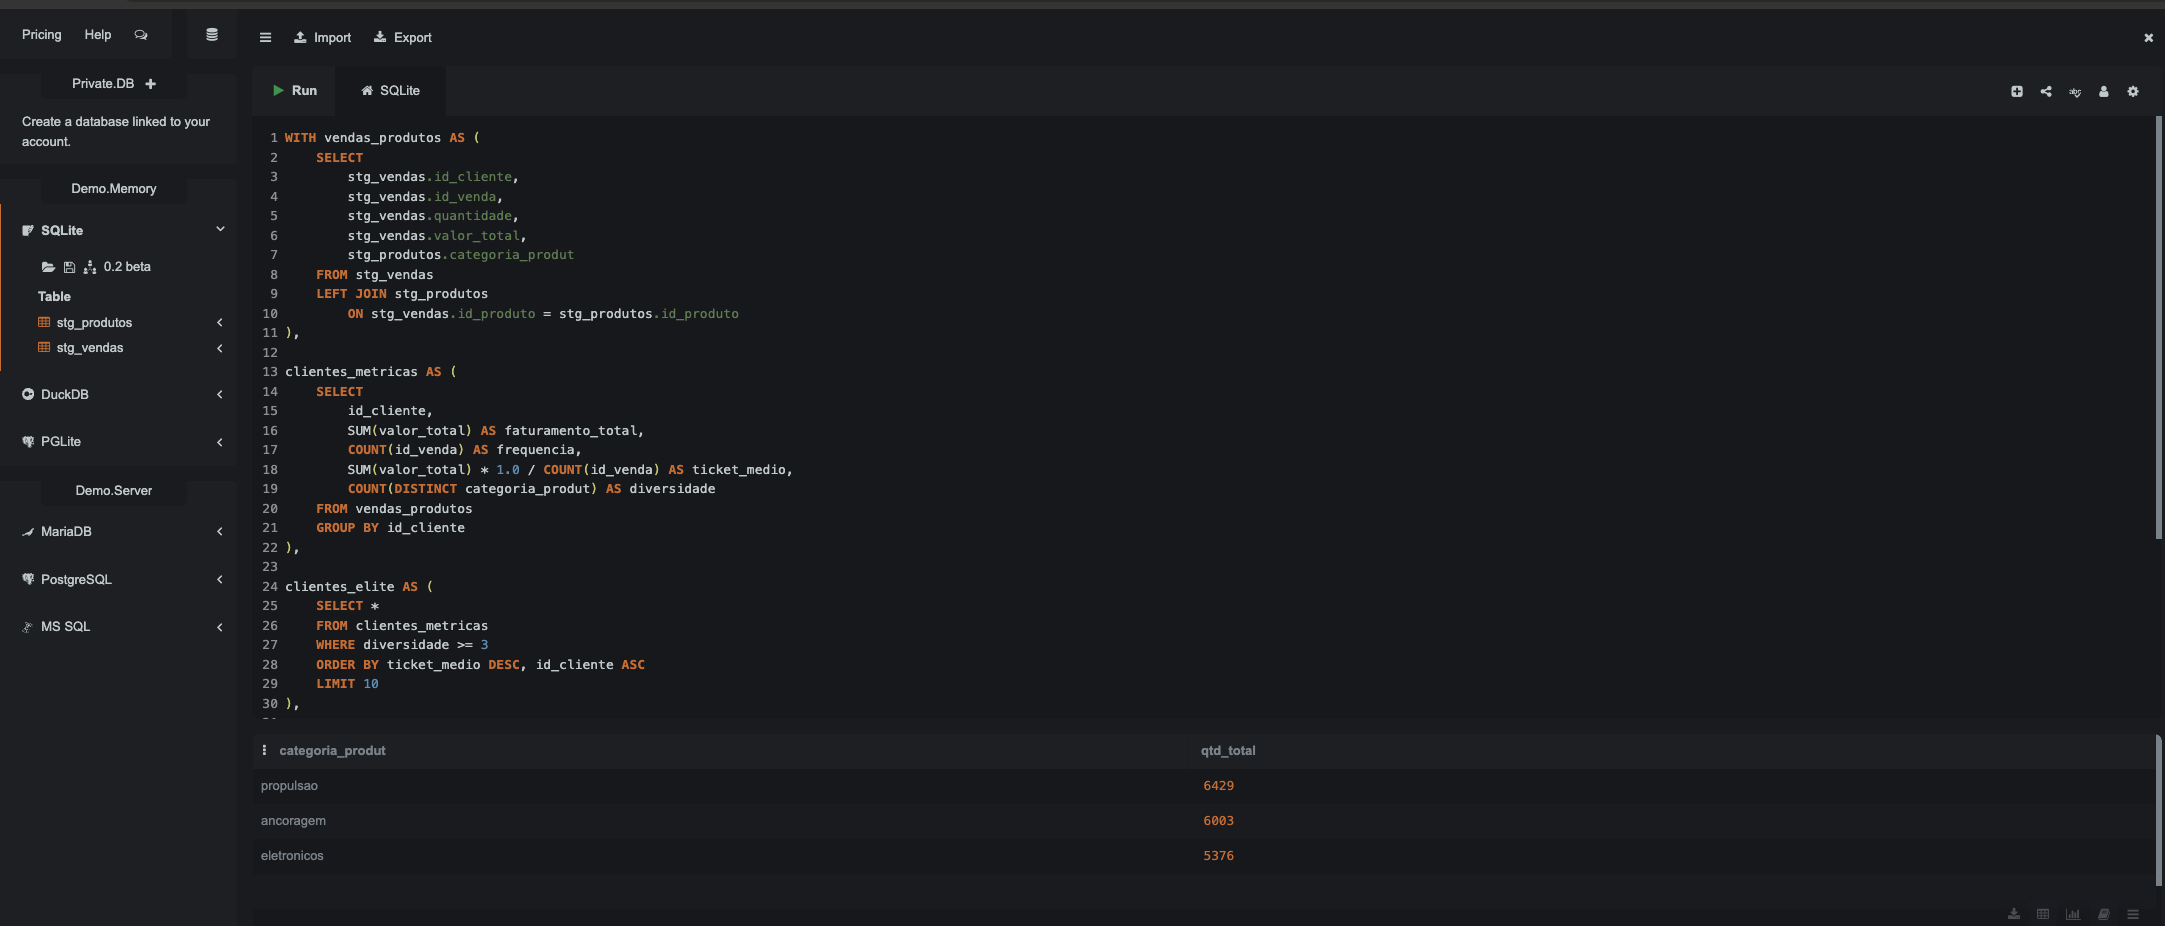

In [850]:
display(Image(filename=IMAGES_PATH / "5_1_codigo.png"))


Questão 5.2 - Validação

Considerando apenas as compras realizadas pelos Top 10
Clientes selecionados (Critério: Maior Ticket Médio com 3 +
categorias): 

Qual foi a categoria de produtos mais
vendida para eles (maior quantidade total de itens)?

Resposta: propulsao


Questão 5.3 - Explique:

1 - Como você realizou a limpeza das categorias?

2 - Qual lógica utilizou para filtrar os clientes com
diversidade mínima?

3 - Como garantiu que a contagem de itens refletisse
apenas os Top 10?

1 - Como você realizou a limpeza das categorias?

Fiz a limpeza das categorias em uma etapa de tratamento dos dados em uma camada staging de dados (todos os códigos estão na pasta notebooks), padronizando todos os valores. Normalizei e padronizei tudo, lowercase, remoção de possíveis inconsistências e uniformizei os nomes das categorias.



2 - Qual lógica utilizou para filtrar os clientes com diversidade mínima?

Calculei a diversidade com a quantidade de categorias diferentes que cada cliente comprou. Usei COUNT(DISTINCT categoria_produt) agrupando por cliente, e depois filtrei apenas os clientes com 3 ou mais categorias, como foi pedido.


3 - Como garantiu que a contagem de itens refletisse apenas os Top 10?

Depois que calculei as métricas por cliente (faturamento total, frequência, ticket médio e diversidade), ordenei os clientes pelo ticket médio em ordem decrescente e para os casos de empate, fiz pelo id_cliente em ordem crescente. Depois, apliquei um LIMIT 10 para saber quais eram os Top 10 clientes.

Para garantir que só esses clientes fossem selecionados na contagem final, fiz um INNER JOIN entre vendas e o subconjunto dos clientes elite. Assim, a agregação das quantidades por categoria considerou apenas as compras desses Top 10 clientes.

## Questão 6 - Dimensão de calendário

Questão 6.1 - Código SQL
Código com:

• Desenvolvimento de u m calendário com os dias d a
semana (em portugues)

• LEFT JOIN entre o calendário e a tabela d e vendas

• agregação de vendas por dia (soma de valor_venda),

• substituição de valores nulos por zero para dias sem
vendas


In [851]:
query_path = SQL_PATH / "6_1_codigo.sql"

with open(query_path, "r", encoding="utf-8") as f:
    query = f.read()

print(f"Link para a query: {SQL_PATH / '6_1_codigo.sql'}")


Link para a query: /Users/richardgomes/lh-nautical-data-project/sql/6_1_codigo.sql


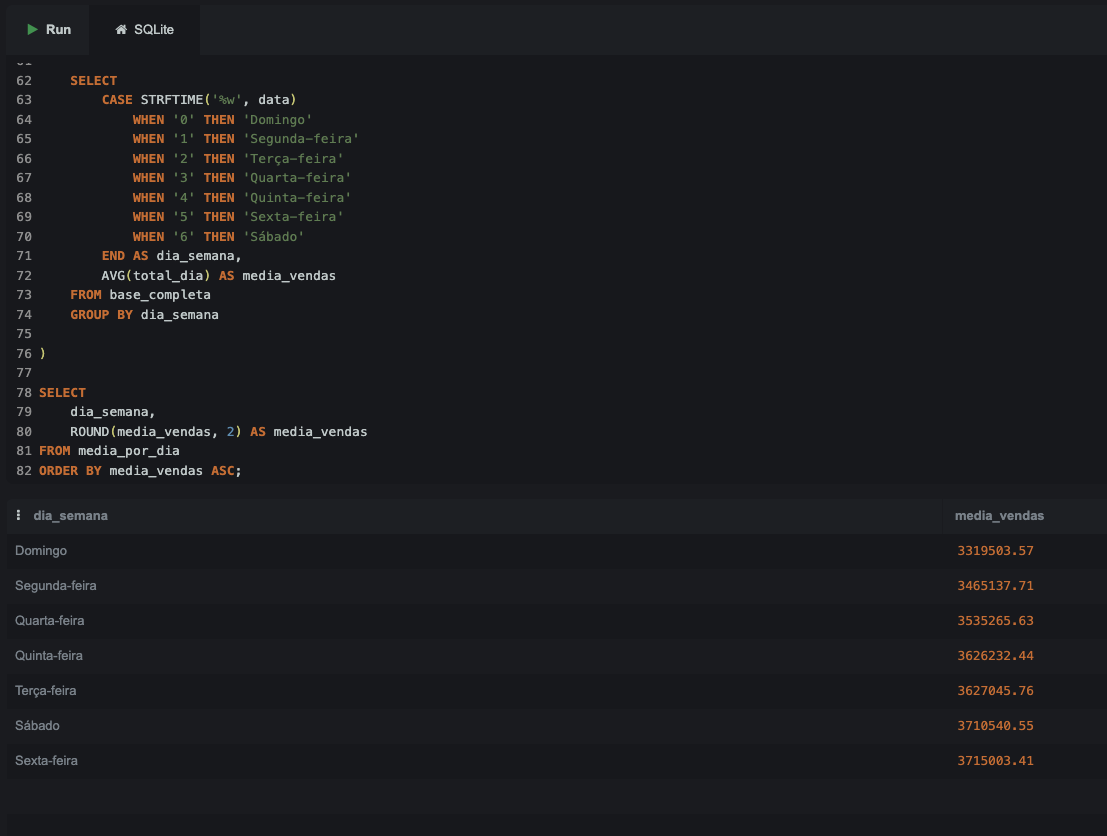

In [852]:
display(Image(filename=IMAGES_PATH / "6_1_codigo.png"))


Prevendo que vou precisar dessas datas em uma dim_date para o dashboard vou gera-la em Python aqui mesmo.

Intervalo de datas (mesmo da sua análise)

In [853]:
date_range = pd.date_range(start="2023-01-01", end="2024-12-31")



Dias da semana já em português

In [854]:

date_range = pd.date_range(start="2023-01-01", end="2024-12-31")

dim_date = pd.DataFrame({
    "data": date_range
})

dim_date["ano"] = dim_date["data"].dt.year
dim_date["mes"] = dim_date["data"].dt.month
dim_date["dia"] = dim_date["data"].dt.day

dim_date["nome_mes"] = dim_date["data"].dt.month_name().map({
    "January": "Janeiro",
    "February": "Fevereiro",
    "March": "Março",
    "April": "Abril",
    "May": "Maio",
    "June": "Junho",
    "July": "Julho",
    "August": "Agosto",
    "September": "Setembro",
    "October": "Outubro",
    "November": "Novembro",
    "December": "Dezembro"
})

dim_date["dia_da_semana_num"] = dim_date["data"].dt.weekday
dim_date["dia_da_semana"] = dim_date["data"].dt.day_name()


traducao = {
    "Monday": "Segunda-feira",
    "Tuesday": "Terça-feira",
    "Wednesday": "Quarta-feira",
    "Thursday": "Quinta-feira",
    "Friday": "Sexta-feira",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

dim_date["dia_da_semana"] = dim_date["dia_da_semana"].map(traducao)
dim_date["fim_de_semana"] = dim_date["dia_da_semana_num"].isin([5, 6])
dim_date["data_chave"] = dim_date["data"].dt.strftime("%Y%m%d").astype(int)


In [855]:
dim_date

,data,ano,mes,dia,nome_mes,dia_da_semana_num,dia_da_semana,fim_de_semana,data_chave
0,2023-01-01,2023,1,1,Janeiro,6,Domingo,True,20230101
1,2023-01-02,2023,1,2,Janeiro,0,Segunda-feira,False,20230102
2,2023-01-03,2023,1,3,Janeiro,1,Terça-feira,False,20230103
3,2023-01-04,2023,1,4,Janeiro,2,Quarta-feira,False,20230104
4,2023-01-05,2023,1,5,Janeiro,3,Quinta-feira,False,20230105
...,...,...,...,...,...,...,...,...,...
726,2024-12-27,2024,12,27,Dezembro,4,Sexta-feira,False,20241227
727,2024-12-28,2024,12,28,Dezembro,5,Sábado,True,20241228
728,2024-12-29,2024,12,29,Dezembro,6,Domingo,True,20241229
729,2024-12-30,2024,12,30,Dezembro,0,Segunda-feira,False,20241230


In [856]:
dim_date.to_csv(MARTS_PATH / "dim_date.csv", index=False)